In [93]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as plt


## Data Importing and Analysis

Using the "American Cheese Prices Raw Dataset (2026)" from Kaggle

In [13]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
df = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS,
                            "costinflation/american-cheese-prices-raw-dataset-2026",
                            "costinflation-american-cheese-retail-prices-raw-2026-07-13-to-2026-08-10.csv")

Download already complete (4545013 bytes).


From visual analysis of the columns, I'll first assess which columns will be useful for analysis. 

In [20]:
df.head(5)

,series_id,series_title,canonical_url,geography_type,geography_id,geography_label,observed_date,product_name,quantity_value,quantity_unit,quantity_name,price_amount,currency_code,normalized_price_amount,normalized_quantity_value,normalized_quantity_unit
0,american_cheese,American cheese,https://costinflation.com/indices/american-che...,postal_code,11385,"New York, NY - Ridgewood/Glendale",2026-07-13,"Amazon Grocery, Pasteurized Process American C...",16.0,ounces,16 ounces,2.48,USD,0.9300,0.375,pounds
1,american_cheese,American cheese,https://costinflation.com/indices/american-che...,postal_code,11385,"New York, NY - Ridgewood/Glendale",2026-07-13,"Amazon Saver, American Singles, Pasteurized Pr...",16.0,ounces,16 ounces,2.48,USD,0.9300,0.375,pounds
2,american_cheese,American cheese,https://costinflation.com/indices/american-che...,postal_code,11385,"New York, NY - Ridgewood/Glendale",2026-07-13,"American cheese slices , contains 9 ingredient...",32.0,ounces,32 ounces,42.99,USD,8.0606,0.375,pounds
3,american_cheese,American cheese,https://costinflation.com/indices/american-che...,postal_code,11385,"New York, NY - Ridgewood/Glendale",2026-07-13,BORDEN CHEESE SLICES AMERICAN SINGLES 12 OZ PA...,36.0,ounces,36 ounces,49.90,USD,8.3167,0.375,pounds
4,american_cheese,American cheese,https://costinflation.com/indices/american-che...,postal_code,11385,"New York, NY - Ridgewood/Glendale",2026-07-13,Borden Lactose Free American Singles 8 Oz (Pac...,24.0,ounces,24 ounces,49.90,USD,12.4750,0.375,pounds


In [ ]:
# These columns have only one unique value each for this dataset, and so will not be used in further analysis
print(f'Unique values in series_id column: {df['series_id'].nunique()}')
print(f'Unique values in series_title column: {df['series_title'].nunique()}')
print(f'Unique values in geography_type column: {df['geography_type'].nunique()}')
print(f'Unique values in currency_code column: {df['currency_code'].nunique()}')

cheese_df = df.drop(columns=['series_id', 'series_title', 'geography_type', 'currency_code']);

# I will also drop these string columns because they are either not useful identifiers or are captured by other columns
cheese_df = cheese_df.drop(columns=['canonical_url', 'quantity_name']);

# Finally, I will drop the 'normalized' columns as I intend to do my own normalization and analysis
cheese_df = cheese_df.drop(columns=['normalized_price_amount', 'normalized_quantity_value', 'normalized_quantity_unit']);

# I'll now add a column for price per ounce. Any rows without a quantity_unit or quantity_value will have to be dropped.
cheese_df = cheese_df.where(cheese_df['quantity_unit'] != 'unknown')
cheese_df['quantity_value'] = cheese_df.apply(lambda row: row['quantity_value']*16.0 if row['quantity_unit'] == 'pounds' else row['quantity_value'], axis=1)
cheese_df = cheese_df.drop(columns=['quantity_unit'])
cheese_df = cheese_df.dropna(subset=['price_amount', 'quantity_value'])
cheese_df['price_per_ounce'] = cheese_df['price_amount'] / cheese_df['quantity_value']

# Convert zip codes to strings
cheese_df['geography_id'] = cheese_df['geography_id'].astype('Int32').astype('str')

# This leaves us with the following columns:
cheese_df.head(5)

Unique values in series_id column: 1
Unique values in series_title column: 1
Unique values in geography_type column: 1
Unique values in currency_code column: 1


,geography_id,geography_label,observed_date,product_name,quantity_value,price_amount,price_per_ounce
0,11385,"New York, NY - Ridgewood/Glendale",2026-07-13,"Amazon Grocery, Pasteurized Process American C...",16.0,2.48,0.155000
1,11385,"New York, NY - Ridgewood/Glendale",2026-07-13,"Amazon Saver, American Singles, Pasteurized Pr...",16.0,2.48,0.155000
2,11385,"New York, NY - Ridgewood/Glendale",2026-07-13,"American cheese slices , contains 9 ingredient...",32.0,42.99,1.343438
3,11385,"New York, NY - Ridgewood/Glendale",2026-07-13,BORDEN CHEESE SLICES AMERICAN SINGLES 12 OZ PA...,36.0,49.90,1.386111
4,11385,"New York, NY - Ridgewood/Glendale",2026-07-13,Borden Lactose Free American Singles 8 Oz (Pac...,24.0,49.90,2.079167


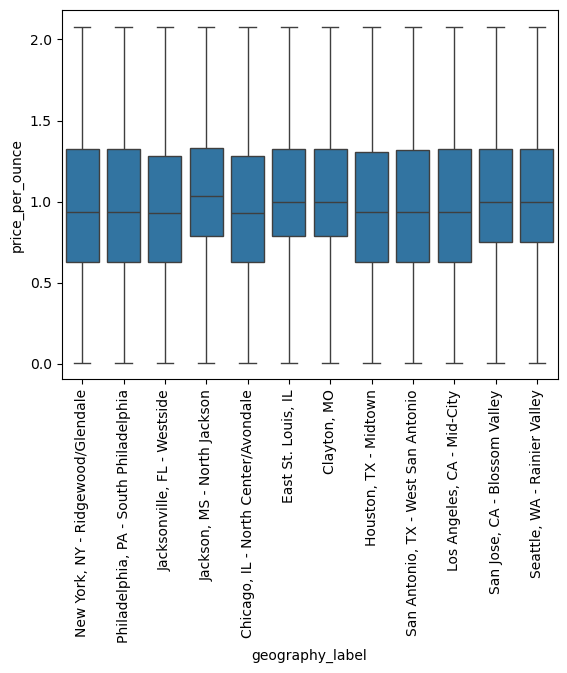

In [ ]:
ax = sns.boxplot(x=cheese_df['geography_label'], y=cheese_df['price_per_ounce'], )
ax.tick_params(axis='x', rotation=90)


The above graph demonstrates relative consistency in average price per ounce. I am somewhat surprised to note a higher median price per ounce in Jackson, MS when I would otherwise have assumed a richer, bigger city like New York would have a higher price. 

I next want to explore the different price modes because there is such a spread in pricing.

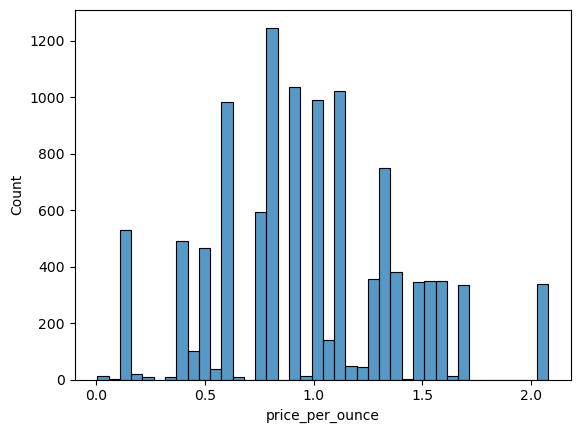

In [99]:
ax = sns.histplot(cheese_df, x='price_per_ounce', multiple='stack')

It's certainly notable that there are well-defined modes here. This, I think, demonstrates less variability in the price of these cheeses by time and location than might otherwise have been assumed. Still, we can apply a few ML models to practice discriminative algorithms, but I do think this may be trivial. I'll first split the data into a few price categories.